<div style="
    background: linear-gradient(135deg, #0f172a, #1e293b);
    padding: 30px;
    border-radius: 18px;
    text-align: center;
    color: white;
    box-shadow: 0 0 25px rgba(0,0,0,0.3);
    margin-bottom: 25px;
">

<h1 style="
    font-size: 42px;
    margin-bottom: 10px;
    font-weight: 800;
">
Market Sentiment vs Trader Behavior
</h1>

<h3 style="
    color: #cbd5e1;
    font-weight: 400;
    margin-top: 0;
">
A Data-Driven Analysis of Hyperliquid Trading Activity
</h3>

<hr style="
    border: 1px solid rgba(255,255,255,0.15);
    margin: 20px 0;
">

<p style="
    font-size: 16px;
    color: #94a3b8;
">
Behavioral Finance • Quantitative Analysis • Market Sentiment Intelligence
</p>

</div>


<br>

# SECTION 1 - Project Objective

## Project Objective :-

The objective of this project is to analyze the relationship between cryptocurrency market sentiment and trader behavior using historical trading activity from Hyperliquid alongside the Bitcoin Fear & Greed Index.

This study focuses on understanding how emotional market conditions such as Fear, Greed, Extreme Fear, and Extreme Greed influence trader profitability, trading activity, execution patterns, and overall behavioral dynamics.

Through quantitative analysis, behavioral profiling, clustering techniques, and sentiment transition analysis, the project aims to uncover meaningful patterns that can support smarter trading strategies and improved risk management in volatile crypto markets.

<br>
<br>

---

# SECTION 2 - Setup & Loading

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from scipy.stats import pearsonr

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

In [2]:
trades = pd.read_csv('/content/historical_data.csv')
sentiment = pd.read_csv('/content/fear_greed_index.csv')

In [3]:
print("TRADES DATASET")
display(trades.head())

print("\nDATASET SHAPE:", trades.shape)

print("\nCOLUMN INFO")
display(trades.info())

print("\nMISSING VALUES")
display(trades.isnull().sum())

TRADES DATASET


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12



DATASET SHAPE: (37109, 16)

COLUMN INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37109 entries, 0 to 37108
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Account           37109 non-null  object 
 1   Coin              37109 non-null  object 
 2   Execution Price   37109 non-null  float64
 3   Size Tokens       37109 non-null  float64
 4   Size USD          37109 non-null  float64
 5   Side              37109 non-null  object 
 6   Timestamp IST     37109 non-null  object 
 7   Start Position    37109 non-null  float64
 8   Direction         37109 non-null  object 
 9   Closed PnL        37109 non-null  float64
 10  Transaction Hash  37109 non-null  object 
 11  Order ID          37108 non-null  float64
 12  Crossed           37108 non-null  object 
 13  Fee               37108 non-null  float64
 14  Trade ID          37108 non-null  float64
 15  Timestamp         37108 non-null  float64
dtyp

None


MISSING VALUES


,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [4]:
print("SENTIMENT DATASET")
display(sentiment.head())

print("\nDATASET SHAPE:", sentiment.shape)

print("\nMISSING VALUES")
display(sentiment.isnull().sum())

SENTIMENT DATASET


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05



DATASET SHAPE: (2644, 4)

MISSING VALUES


,0
timestamp,0
value,0
classification,0
date,0


In [5]:
print("Trades Dataset Columns:\n")
print(trades.columns.tolist())

print("\nSentiment Dataset Columns:\n")
print(sentiment.columns.tolist())

Trades Dataset Columns:

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

Sentiment Dataset Columns:

['timestamp', 'value', 'classification', 'date']


## Insights :-

- The trading dataset contains detailed execution-level information including pnl, fees, trade direction, and position activity, enabling behavioral analysis of market participants.
- The sentiment dataset provides daily market psychology indicators, making it possible to study trader performance under varying emotional market conditions.
- The combination of transactional and sentiment-level data creates a strong foundation for sentiment-driven behavioral analytics.

<br>
<br>

---

# SECTION 3 - Preprocessing

In [6]:
trades.columns = (
    trades.columns
    .str.lower()
    .str.strip()
    .str.replace(' ', '_')
)

sentiment.columns = (
    sentiment.columns
    .str.lower()
    .str.strip()
    .str.replace(' ', '_')
)

print("Cleaned Trades Columns:\n")
print(trades.columns.tolist())

print("\nCleaned Sentiment Columns:\n")
print(sentiment.columns.tolist())

Cleaned Trades Columns:

['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side', 'timestamp_ist', 'start_position', 'direction', 'closed_pnl', 'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id', 'timestamp']

Cleaned Sentiment Columns:

['timestamp', 'value', 'classification', 'date']


In [7]:
trades['timestamp_ist'] = pd.to_datetime(
    trades['timestamp_ist'],
    format='%d-%m-%Y %H:%M'
)

trades['date'] = trades['timestamp_ist'].dt.date

sentiment['date'] = pd.to_datetime(
    sentiment['date']
).dt.date

In [8]:
print("Trade Date Range:")
print(trades['date'].min(), "to", trades['date'].max())

print("\nSentiment Date Range:")
print(sentiment['date'].min(), "to", sentiment['date'].max())

Trade Date Range:
2024-01-19 to 2025-05-01

Sentiment Date Range:
2018-02-01 to 2025-05-02


In [9]:
min_date = trades['date'].min()
max_date = trades['date'].max()

sentiment = sentiment[
    (sentiment['date'] >= min_date) &
    (sentiment['date'] <= max_date)
]

print("Filtered Sentiment Shape:", sentiment.shape)

Filtered Sentiment Shape: (468, 4)


In [10]:
df = pd.merge(
    trades,
    sentiment[['date', 'classification', 'value']],
    on='date',
    how='left'
)

print("Merged Dataset Shape:", df.shape)

df.head()

Merged Dataset Shape: (37109, 19)


,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


In [11]:
print("Missing Values After Merge:\n")

display(df.isnull().sum())

print("\nUnique Market Sentiments:\n")

print(df['classification'].value_counts())

Missing Values After Merge:



,0
account,0
coin,0
execution_price,0
size_tokens,0
size_usd,0
side,0
timestamp_ist,0
start_position,0
direction,0
closed_pnl,0



Unique Market Sentiments:

classification
Fear             10909
Greed             9944
Extreme Greed     7957
Neutral           6789
Extreme Fear      1504
Name: count, dtype: int64


## Insights :-

- Trade and sentiment datasets were successfully aligned using date-level temporal mapping.
- The filtered sentiment data precisely matched the trading activity period, ensuring consistency in downstream analysis.
- Post-merge validation showed no significant missing values, indicating reliable integration between trading and sentiment information.

<br>
<br>

---

# SECTION 4 - Feature Engineering

In [12]:
df['is_profit'] = (
    df['closed_pnl'] > 0
).astype(int)

df['trade_value_ratio'] = (
    df['closed_pnl'] / (df['size_usd'] + 1)
)

df['fee_ratio'] = (
    df['fee'] / (df['size_usd'] + 1)
)

df['is_buy'] = (
    df['side'] == 'BUY'
).astype(int)

df['sentiment_score'] = df['value']

df['high_fear'] = (
    df['classification']
    .isin(['Fear', 'Extreme Fear'])
).astype(int)

df['high_greed'] = (
    df['classification']
    .isin(['Greed', 'Extreme Greed'])
).astype(int)

In [13]:
df[
    [
        'closed_pnl',
        'size_usd',
        'fee',
        'sentiment_score'
    ]
].describe()

,closed_pnl,size_usd,fee,sentiment_score
count,37109.000000,3.710900e+04,37108.000000,37103.000000
mean,108.990773,1.766657e+04,3.551804,55.154058
std,1645.668796,8.013641e+04,13.817601,18.406239
min,-117990.104100,0.000000e+00,-1.175712,10.000000
25%,0.000000,4.513700e+02,0.016774,43.000000
50%,0.000000,1.610850e+03,0.217091,54.000000
75%,19.955184,9.999880e+03,2.238675,72.000000
max,135329.090100,3.921431e+06,837.471593,94.000000


## Insights :-

- The dataset exhibits high variability in trade profitability, indicating the presence of both extreme gains and substantial losses.
- Trading activity spans a wide range of trade sizes and fee levels, reflecting heterogeneous trader behavior and capital exposure.
- Engineered behavioral features such as profitability ratios and sentiment indicators enable deeper trader-performance analysis.

<br>
<br>

---

# SECTION 5 - Exploratory Data Analysis

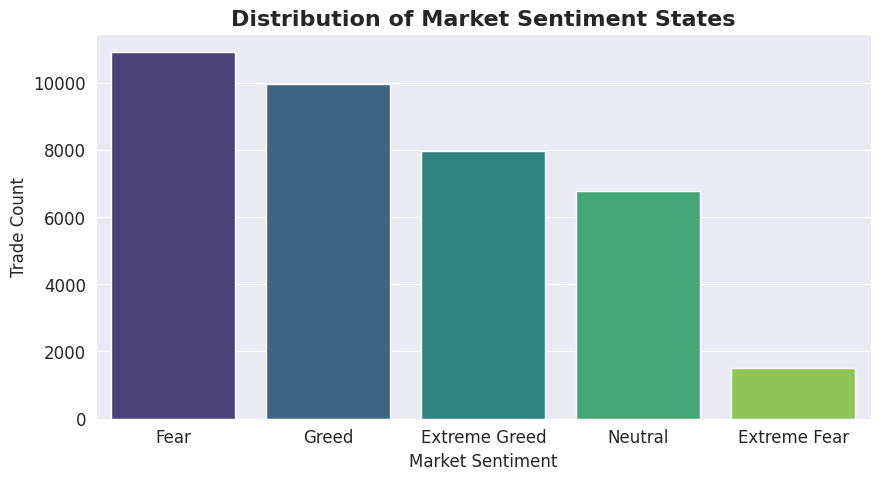

In [14]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='classification',
    order=df['classification'].value_counts().index,
    palette='viridis'
)

plt.title(
    'Distribution of Market Sentiment States',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Market Sentiment')
plt.ylabel('Trade Count')

plt.show()

## Insights :-

- Fear and Greed market conditions dominated the dataset, while Extreme Fear periods occurred relatively infrequently.
- The distribution suggests that most trading activity occurred during emotionally active market environments rather than neutral conditions.
- Market sentiment cycles appear sufficiently diverse to support comparative behavioral analysis.

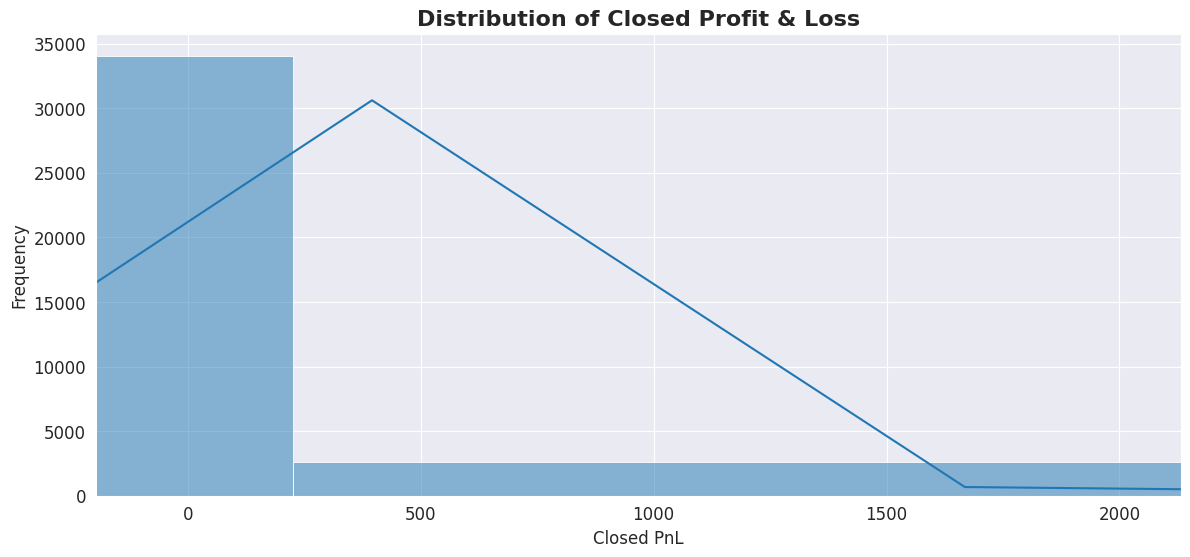

In [15]:
plt.figure(figsize=(14,6))

sns.histplot(
    df['closed_pnl'],
    bins=120,
    kde=True
)

plt.xlim(
    df['closed_pnl'].quantile(0.01),
    df['closed_pnl'].quantile(0.99)
)

plt.title(
    'Distribution of Closed Profit & Loss',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Closed PnL')
plt.ylabel('Frequency')

plt.show()

## Insights :-

- The pnl distribution is heavily skewed, with the majority of trades clustered around smaller profitability ranges.
- A limited number of extreme profit events contributed disproportionately large outcomes compared to the rest of the dataset.
- The presence of significant positive and negative outliers indicates elevated volatility within trader performance.

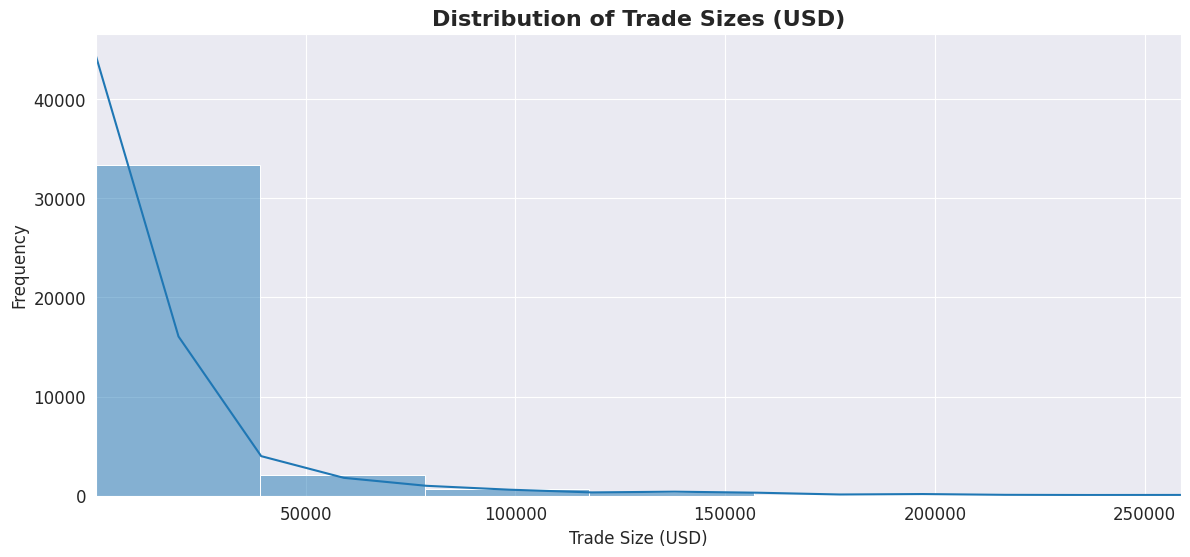

In [16]:
plt.figure(figsize=(14,6))

sns.histplot(
    df['size_usd'],
    bins=100,
    kde=True
)

plt.xlim(
    df['size_usd'].quantile(0.01),
    df['size_usd'].quantile(0.99)
)

plt.title(
    'Distribution of Trade Sizes (USD)',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Trade Size (USD)')
plt.ylabel('Frequency')

plt.show()

## Insights :-

- Trade size distribution is strongly right-skewed, indicating the presence of high-volume execution activity by a smaller subset of traders.
- Most trades were executed with comparatively lower capital exposure, while a minority contributed very large position sizes.
- This imbalance suggests uneven market participation and potential whale-driven trading behavior.

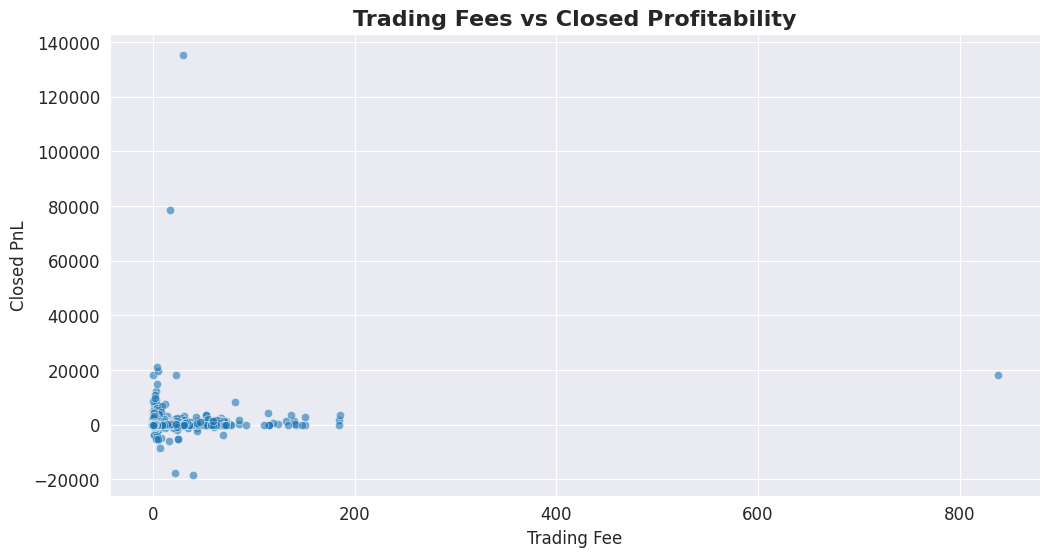

In [17]:
sample_df = df.sample(
    min(10000, len(df)),
    random_state=42
)

plt.figure(figsize=(12,6))

sns.scatterplot(
    data=sample_df,
    x='fee',
    y='closed_pnl',
    alpha=0.6
)

plt.title(
    'Trading Fees vs Closed Profitability',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Trading Fee')
plt.ylabel('Closed PnL')

plt.show()

## Insights :-

- Trading fees generally increased alongside higher activity and larger trade execution sizes.
- Several high-fee trades still resulted in negative pnl outcomes, indicating that aggressive participation did not consistently improve profitability.
- Profitability dispersion remained high even among similar fee ranges, suggesting inconsistent execution efficiency across traders.

<br>
<br>

---

# SECTION 6 - Behavorial Analysis

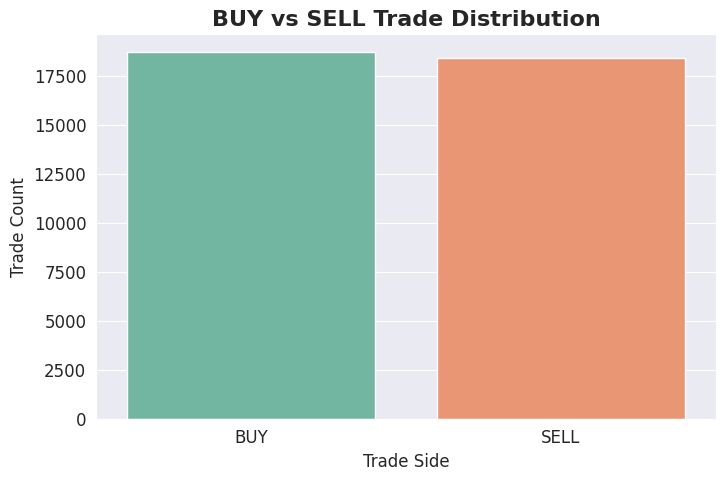

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='side',
    palette='Set2'
)

plt.title(
    'BUY vs SELL Trade Distribution',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Trade Side')
plt.ylabel('Trade Count')

plt.show()

## Insights :-

- BUY and SELL activity remained relatively balanced throughout the dataset, indicating active participation on both sides of the market.
- The absence of a strong directional imbalance suggests that traders frequently adapted positioning based on changing market conditions.
- Balanced directional participation may also reflect short-term speculative trading behavior rather than long-term holding strategies.

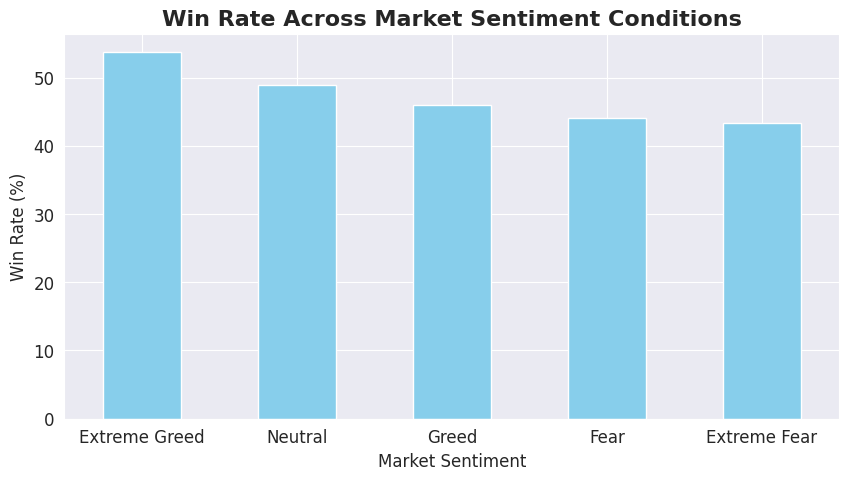

In [19]:
winrate = (
    df.groupby('classification')['is_profit']
    .mean()
    .sort_values(ascending=False)
    * 100
)

plt.figure(figsize=(10,5))

winrate.plot(
    kind='bar',
    color='skyblue'
)

plt.title(
    'Win Rate Across Market Sentiment Conditions',
    fontsize=16,
    fontweight='bold'
)

plt.ylabel('Win Rate (%)')
plt.xlabel('Market Sentiment')

plt.xticks(rotation=0)

plt.show()

## Insights :-

- Trader win rates varied noticeably across sentiment regimes, with Extreme Greed conditions showing the highest success rate.
- Fear-based market conditions were associated with lower trading consistency and weaker profitability outcomes.
- The results suggest that emotional market environments may influence trader decision-making quality and execution effectiveness.

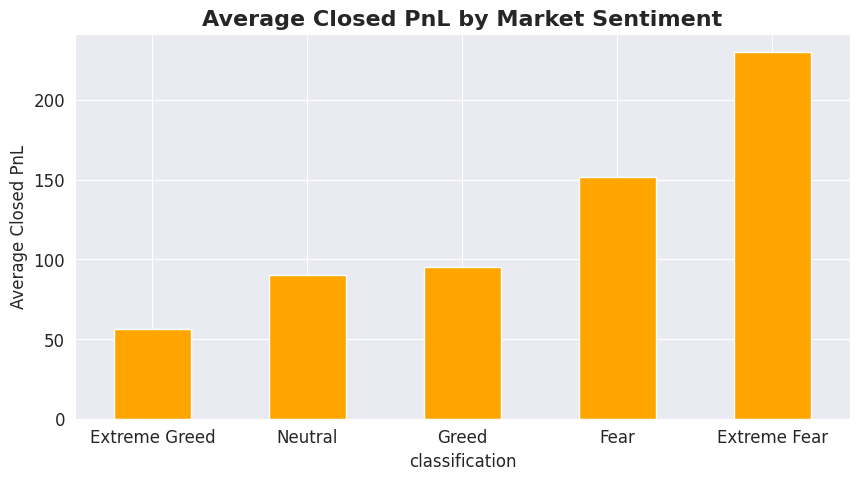

In [20]:
avg_pnl = (
    df.groupby('classification')['closed_pnl']
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,5))

avg_pnl.plot(
    kind='bar',
    color='orange'
)

plt.title(
    'Average Closed PnL by Market Sentiment',
    fontsize=16,
    fontweight='bold'
)

plt.ylabel('Average Closed PnL')

plt.xticks(rotation=0)

plt.show()

## Insights :-

- Average profitability increased substantially during Extreme Fear periods despite lower overall market confidence.
- Greed-driven market conditions generated comparatively lower average pnl outcomes despite elevated participation levels.
- This pattern may indicate that contrarian or disciplined trading strategies performed better during panic-driven environments.

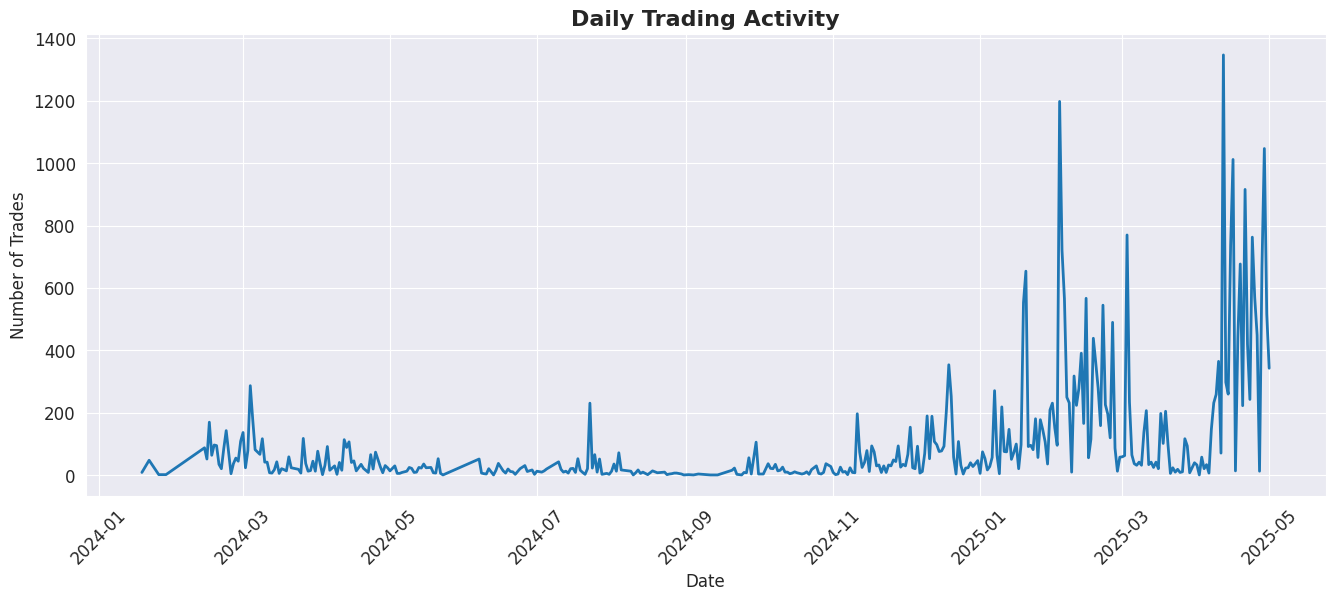

In [21]:
daily_trades = (
    df.groupby('date')
    .size()
    .reset_index(name='trade_count')
)

plt.figure(figsize=(16,6))

sns.lineplot(
    data=daily_trades,
    x='date',
    y='trade_count',
    linewidth=2
)

plt.title(
    'Daily Trading Activity',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Date')
plt.ylabel('Number of Trades')

plt.xticks(rotation=45)

plt.show()

## Insights :-

- Trading activity intensified significantly during the later portion of the observed timeline, particularly throughout 2025.
- Multiple sharp spikes in participation indicate periods of heightened volatility and speculative market behavior.
- The increasing activity trend suggests rising market engagement and stronger emotional participation over time.

<br>
<br>

---

# SECTION 7 - Trader Profiling

In [22]:
trader_metrics = df.groupby('account').agg({
    'closed_pnl': ['sum', 'mean', 'std'],
    'size_usd': ['mean', 'sum'],
    'fee': 'sum',
    'is_profit': 'mean',
    'trade_id': 'count'
})

trader_metrics.columns = [
    'total_pnl',
    'avg_pnl',
    'pnl_volatility',
    'avg_trade_size',
    'total_volume',
    'total_fees',
    'win_rate',
    'trade_count'
]

trader_metrics = trader_metrics.reset_index()

trader_metrics['win_rate'] *= 100

trader_metrics.head()

,account,total_pnl,avg_pnl,pnl_volatility,avg_trade_size,total_volume,total_fees,win_rate,trade_count
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,419.127768,4692.452329,16159.576734,6.169726e+07,7405.312304,35.961236,3818
1,0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05,336.735548,1649.497580,2397.824753,2.966109e+06,747.006931,48.423605,1237
2,0x4f93fead39b70a1824f981a54d4e55b278e9f760,3.089759e+05,40.740489,656.693628,17098.171055,1.296725e+08,40724.467403,36.036392,7584
3,0x513b8629fe877bb581bf244e326a047b249c4ff1,8.404226e+05,68.684419,639.402444,34396.580284,4.208766e+08,76424.642892,40.119320,12236
4,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,4.030115e+05,281.826227,1591.523958,2133.667364,3.051144e+06,290.011048,30.629371,1430


## Insights :-

- Trader-level aggregation revealed substantial variation in profitability, activity levels, and execution consistency.
- Certain accounts demonstrated significantly higher trading volume and pnl generation compared to the broader trader population.
- The variability across behavioral metrics supports the existence of distinct trader profiles within the ecosystem.

In [23]:
top_traders = trader_metrics.sort_values(
    by='total_pnl',
    ascending=False
).head(10)

top_traders

,account,total_pnl,avg_pnl,pnl_volatility,avg_trade_size,total_volume,total_fees,win_rate,trade_count
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,419.127768,4692.452329,16159.576734,6.169726e+07,7405.312304,35.961236,3818
3,0x513b8629fe877bb581bf244e326a047b249c4ff1,8.404226e+05,68.684419,639.402444,34396.580284,4.208766e+08,76424.642892,40.119320,12236
1,0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05,336.735548,1649.497580,2397.824753,2.966109e+06,747.006931,48.423605,1237
4,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,4.030115e+05,281.826227,1591.523958,2133.667364,3.051144e+06,290.011048,30.629371,1430
5,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,3.419977e+05,41.056146,185.702969,2838.955028,2.364850e+07,2275.275774,80.828331,8329
2,0x4f93fead39b70a1824f981a54d4e55b278e9f760,3.089759e+05,40.740489,656.693628,17098.171055,1.296725e+08,40724.467403,36.036392,7584
7,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,6.784562e+04,120.507317,474.809837,2979.441776,1.677426e+06,548.729265,40.852575,563
6,0x8381e6d82f1affd39a336e143e081ef7620a3b7f,6.551366e+04,34.282396,325.755610,6279.002287,1.199917e+07,3384.882219,33.019362,1911


## Insights :-

- A small number of traders accounted for a disproportionately large share of cumulative profitability.
- High-performing traders generally combined elevated activity levels with larger capital exposure.
- Profit concentration among a limited subset of participants suggests uneven skill distribution across the trading population.

In [25]:
features = trader_metrics[
    [
        'total_pnl',
        'avg_pnl',
        'pnl_volatility',
        'avg_trade_size',
        'win_rate',
        'trade_count'
    ]
].fillna(0)

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

trader_metrics['cluster'] = kmeans.fit_predict(
    scaled_features
)

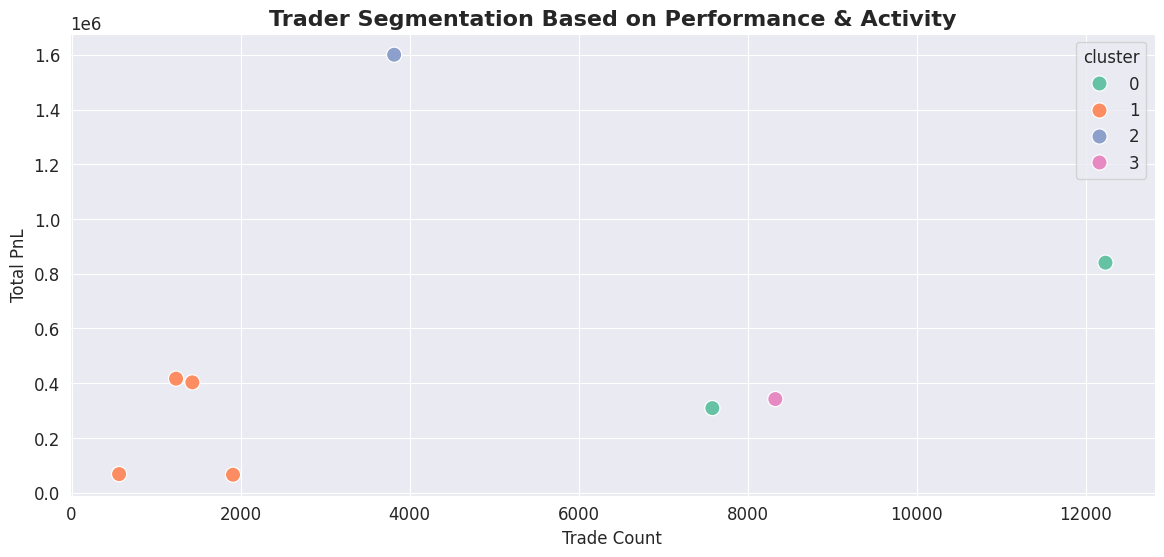

In [26]:
plt.figure(figsize=(14,6))

sns.scatterplot(
    data=trader_metrics,
    x='trade_count',
    y='total_pnl',
    hue='cluster',
    palette='Set2',
    s=120
)

plt.title(
    'Trader Segmentation Based on Performance & Activity',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Trade Count')
plt.ylabel('Total PnL')

plt.show()

## Insights :-

- Clustering analysis identified distinct trader groups based on profitability and trading activity patterns.
- Certain clusters displayed extremely high profitability alongside elevated trade frequency, indicating aggressive but effective participation.
- Other clusters showed lower pnl generation despite moderate activity, suggesting inconsistent execution performance.

<br>
<br>

---

# SECTION 8 - Risk & Correlation Analysis

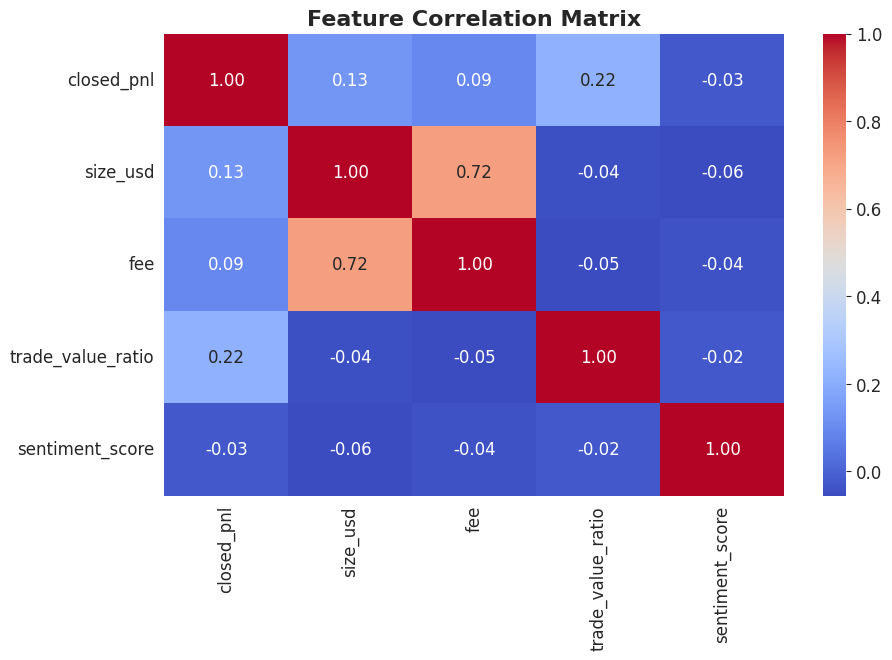

In [27]:
corr_cols = [
    'closed_pnl',
    'size_usd',
    'fee',
    'trade_value_ratio',
    'sentiment_score'
]

corr = df[corr_cols].corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title(
    'Feature Correlation Matrix',
    fontsize=16,
    fontweight='bold'
)

plt.show()

## Insights :-

- Trade size and trading fees exhibited a strong positive correlation, reflecting higher execution costs for larger positions.
- Closed pnl showed relatively weak direct correlation with sentiment score, suggesting that profitability depended more heavily on execution quality and strategy.
- Trade value efficiency metrics demonstrated limited linear dependence on market sentiment, indicating complex behavioral dynamics.

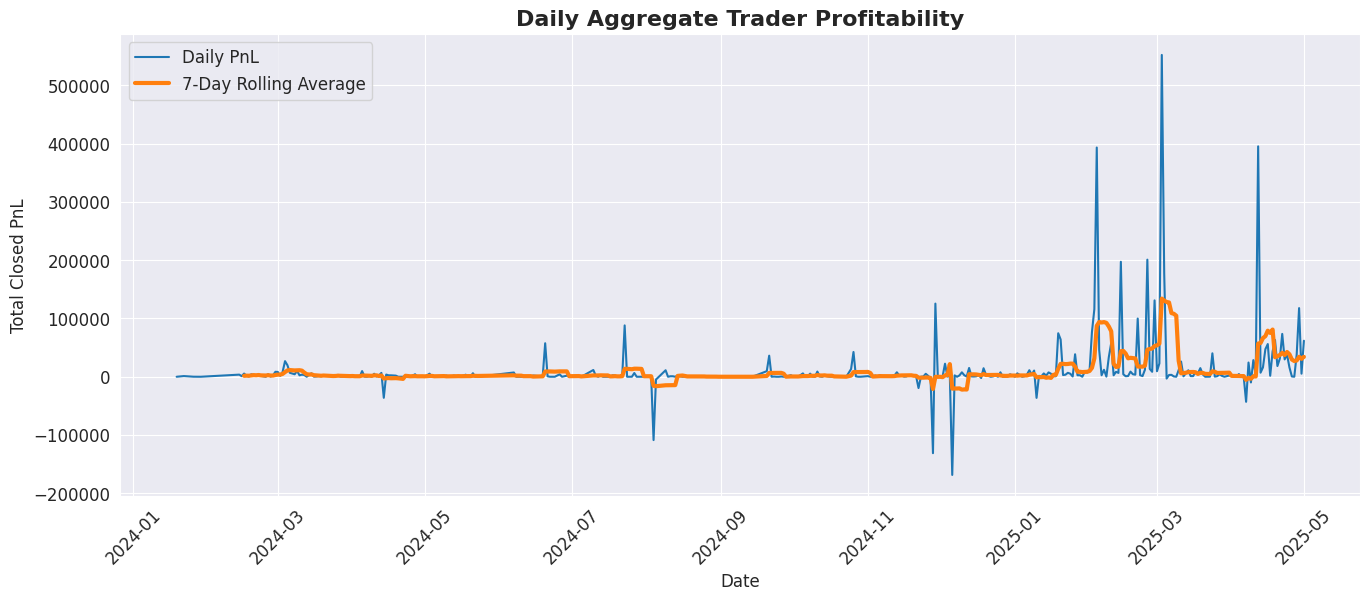

In [28]:
daily_pnl = df.groupby('date')[
    'closed_pnl'
].sum().reset_index()

daily_pnl['rolling_avg'] = (
    daily_pnl['closed_pnl']
    .rolling(7)
    .mean()
)

plt.figure(figsize=(16,6))

sns.lineplot(
    data=daily_pnl,
    x='date',
    y='closed_pnl',
    label='Daily PnL'
)

sns.lineplot(
    data=daily_pnl,
    x='date',
    y='rolling_avg',
    label='7-Day Rolling Average',
    linewidth=3
)

plt.title(
    'Daily Aggregate Trader Profitability',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Date')
plt.ylabel('Total Closed PnL')

plt.xticks(rotation=45)

plt.show()

## Insights :-

- Aggregate trader profitability became substantially more volatile during late 2024 and early 2025.
- Large positive and negative pnl spikes indicate periods of heightened market instability and aggressive speculative behavior.
- The rolling average trend suggests increasing profitability momentum despite short-term fluctuations and drawdowns.

<br>
<br>

---

# SECTION 9 - Sentiment Transition Analysis

In [29]:
daily_sentiment = sentiment.sort_values('date')

daily_sentiment['prev_sentiment'] = (
    daily_sentiment['classification'].shift(1)
)

daily_sentiment['transition'] = (
    daily_sentiment['prev_sentiment'].astype(str)
    + ' → ' +
    daily_sentiment['classification'].astype(str)
)

df = pd.merge(
    df,
    daily_sentiment[['date', 'transition']],
    on='date',
    how='left'
)

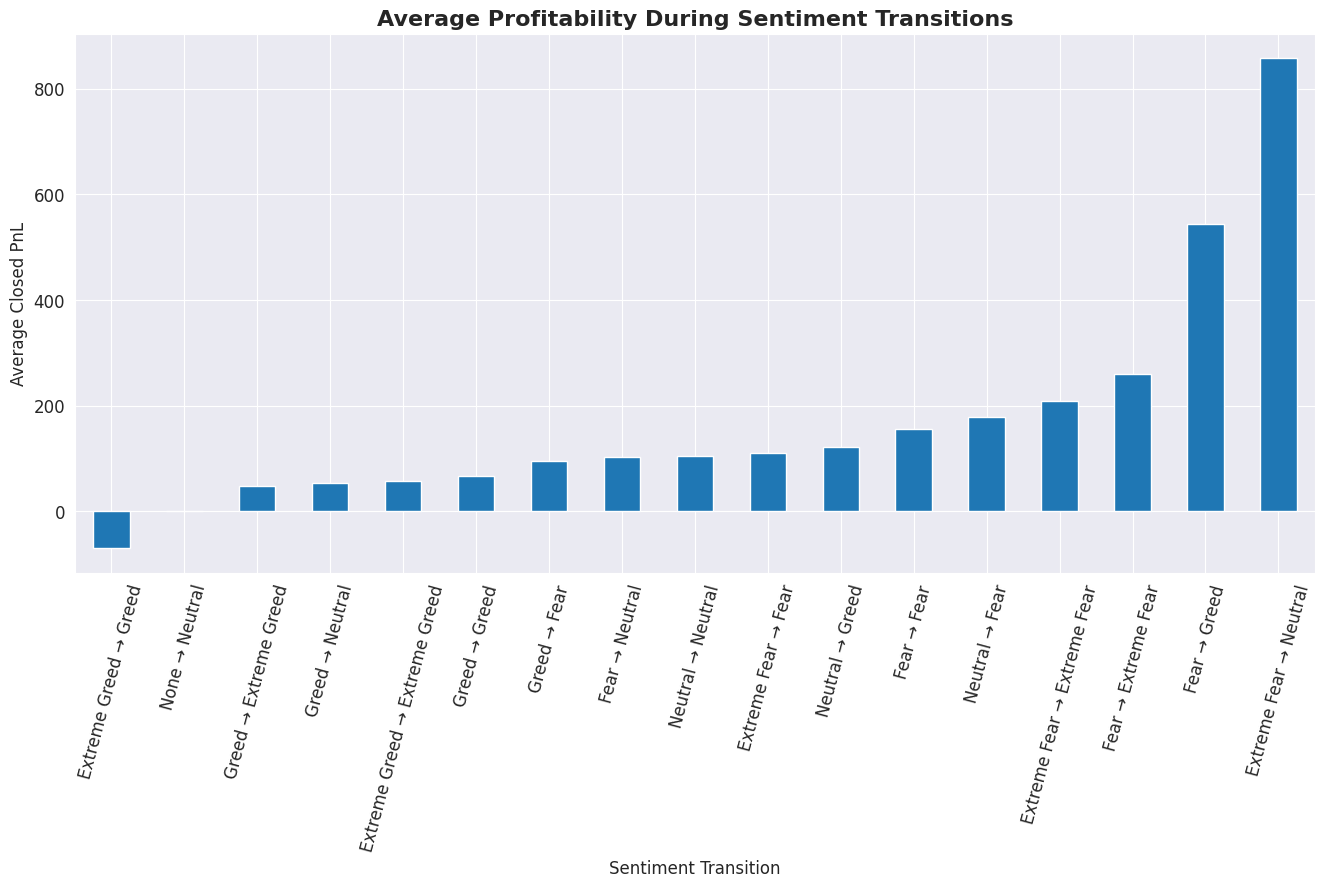

In [30]:
transition_pnl = (
    df.groupby('transition')['closed_pnl']
    .mean()
    .sort_values()
)

plt.figure(figsize=(16,7))

transition_pnl.plot(kind='bar')

plt.title(
    'Average Profitability During Sentiment Transitions',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Sentiment Transition')
plt.ylabel('Average Closed PnL')

plt.xticks(rotation=75)

plt.show()

## Insights :-

- Profitability varied significantly across sentiment transition states, highlighting the importance of emotional market shifts.
- Transitions from Fear toward Neutral or Greed conditions were associated with the strongest average pnl outcomes.
- Certain transition phases generated negative profitability, suggesting elevated uncertainty and unstable trader positioning during abrupt emotional reversals.

<br>
<br>

---

# SECTION 10 - Final Conculsions

<br>

> ## Key Findings :-

- Trader profitability and behavioral patterns varied significantly across different market sentiment conditions.
- Extreme Fear environments generated the highest average pnl outcomes despite lower market confidence.
- Trading activity and aggregate profitability volatility increased sharply during late 2024 and early 2025.
- A small subset of traders contributed disproportionately large profitability relative to the broader population.
- Sentiment transition periods demonstrated substantial impact on trader performance and market stability.

<br>
<br>

> ## Strategic recommendations :-

- Incorporate sentiment-aware risk management during emotionally volatile market phases.
- Monitor trader behavioral shifts during sentiment transitions to identify instability and overexposure risk.
- Develop trader profiling systems to distinguish disciplined participants from high-risk speculative behavior.
- Use volatility-sensitive position sizing strategies during periods of elevated market uncertainty.
- Combine behavioral analytics with real-time market indicators for improved trading decision support.

<br>
<br>

> ## Limitations :-

- The analysis relies primarily on historical execution and sentiment data without incorporating external macroeconomic or orderbook variables.
- Market microstructure information such as liquidation data, funding rates, and depth metrics was unavailable.
- The analysis focuses on observational relationships and does not establish direct causality between sentiment and profitability.
- Certain extreme pnl outliers may influence aggregate statistical behavior.

<br>
<br>

> ## Future work :-

- Develop predictive machine learning models for trader profitability forecasting under varying sentiment conditions.
- Incorporate real-time sentiment feeds and live trading activity for dynamic behavioral monitoring.
- Extend clustering analysis using advanced unsupervised learning techniques and anomaly detection methods.
- Explore reinforcement learning and adaptive trading strategies based on sentiment-driven market behavior.
- Integrate additional market indicators such as volatility indices, liquidation metrics, and funding rates.

<br>
<br>

> ## Conclusion :-
>
> This analysis demonstrated that market sentiment plays a meaningful role in shaping trader behavior, profitability dynamics, and trading activity patterns within the Hyperliquid ecosystem.
>
> The results revealed substantial behavioral differences across emotional market conditions, with trader performance varying considerably during Fear, Greed, and sentiment transition phases.
>
> Overall, the study highlights the importance of combining behavioral analytics, sentiment intelligence, and risk-aware trading strategies to better understand market participant behavior in highly volatile crypto environments.

<div style="
    margin-top: 50px;
    padding: 25px;
    background: linear-gradient(135deg, #111827, #1f2937);
    border-radius: 16px;
    text-align: center;
    color: white;
    box-shadow: 0 0 20px rgba(0,0,0,0.25);
">

<h2 style="
    margin-bottom: 8px;
    font-weight: 700;
">
Thank You
</h2>

<p style="
    color: #cbd5e1;
    font-size: 15px;
    margin-bottom: 20px;
">
This project explores the relationship between crypto market sentiment and trader behavior using quantitative and behavioral analysis techniques.
</p>

<hr style="
    border: 1px solid rgba(255,255,255,0.12);
    margin: 20px 0;
">

<p style="
    font-size: 14px;
    color: #94a3b8;
">
Developed by <b>Bhavesh Gudlani</b><br>
Data Science Internship Assessment Submission
</p>

<p style="
    font-size: 13px;
    color: #64748b;
    margin-top: 15px;
">
Python • Pandas • Scikit-learn • Behavioral Analytics • Data Visualization
</p>

</div>